# Miniproyecto: Clasificación Multi-Etiqueta de Artículos de Noticias de la BBC usando Transformers

**Curso:** Técnicas de Deep Learning  

**Dataset:** "jacopoferretti/bbc-articles-dataset" (Kaggle) — 2225 documentos, 5 clases

**Grupo:** 24

**Integrantes:** Jaime Rodriguez, Juan Martin Santos, Yezid Garcia

## Descripción del problema

Se necesita desarrollar un modelo basado en transformers capaz de clasificar textos de noticias en cuatro categorias como "Sport", "Bussiness", "Politics", "Tech", entre otros. Para esto se toma como base el data set de Kaggle "The BBC Articles Dataset with Extra Features" curado por Jacopo Ferretti.

## Tabla de contenido

1. [Importación de Librerías y Configuración](#1)
2. [Dataset](#2)
3. [Procesamiento de texto](#3)
4. [Implementación de la Arquitectura de Transformers](#4)
5. [Entrenamiento y Evaluación del Modelo](#5)


## 1. Importación de Librerías y Configuración
<a id='1'></a>

Se utilizan las siguientes librerías: `kagglehub` para descargar el dataset desde Kaggle; `pandas` y `numpy` para manipulación de datos tabulares; `torch` y sus módulos `nn` y `DataLoader` para definir y entrenar el modelo en PyTorch; `transformers` de Hugging Face para cargar el tokenizador `DistilBertTokenizer` y el modelo `DistilBertForSequenceClassification` preentrenado; `sklearn` para dividir el dataset en conjuntos de entrenamiento y prueba y calcular métricas de evaluación; `matplotlib` para visualizar la distribución de categorías.


In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support
import kagglehub
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")


Dispositivo: cpu


## 2. Dataset
<a id='2'></a>

El dataset se descarga usando la librería `kagglehub` con el identificador `jacopoferretti/bbc-articles-dataset`. Contiene 2225 artículos de noticias de la BBC clasificados en cinco categorías: *business*, *entertainment*, *politics*, *sport* y *tech*. Cada fila contiene un identificador de artículo, el texto completo del artículo y su categoría asignada.


In [3]:
path = kagglehub.dataset_download("jacopoferretti/bbc-articles-dataset")
print(f"Ruta del dataset: {path}")


100%|██████████| 5.50M/5.50M [00:00<00:00, 23.6MB/s]

Extracting files...
Ruta del dataset: /home/jaime/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16


In [4]:
# Buscar archivos CSV en la ruta del dataset
archivos_csv = []
for raiz, dirs, archivos in os.walk(path):
    for archivo in archivos:
        if archivo.endswith('.csv'):
            archivos_csv.append(os.path.join(raiz, archivo))

print(f"Archivos encontrados: {archivos_csv}")

df = pd.read_csv(archivos_csv[0])
# Normalizar nombres de columnas a minúsculas
df.columns = [c.lower() for c in df.columns]
print(f"Columnas: {df.columns.tolist()}")
print(f"Tamaño: {df.shape}")


Archivos encontrados: ['/home/jaime/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16/bbc_news_text_complexity_summarization.csv', '/home/jaime/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16/archive (2)/bbc-news-data.csv', '/home/jaime/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16/archive/bbc_text_cls.csv']
Columnas: ['text', 'labels', 'no_sentences', 'flesch reading ease score', 'dale-chall readability score', 'text_rank_summary', 'lsa_summary']
Tamaño: (2127, 7)


In [5]:
df.head(5)


,text,labels,no_sentences,flesch reading ease score,dale-chall readability score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...


labels
sport            505
business         503
politics         403
entertainment    369
tech             347
Name: count, dtype: int64


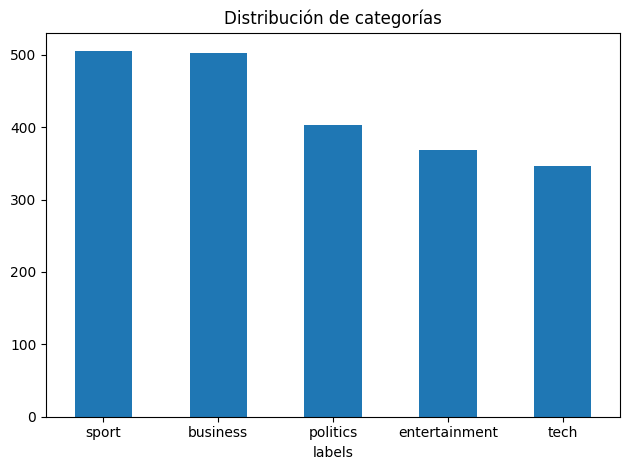

In [7]:
conteo = df['labels'].value_counts()
print(conteo)
conteo.plot(kind='bar', title='Distribución de categorías', rot=0)
plt.tight_layout()
plt.show()


In [9]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
df = df.dropna(subset=['text', 'labels']).reset_index(drop=True)
print(f"\nTamaño final del dataset: {df.shape}")


Valores nulos por columna:
text                            0
labels                          0
no_sentences                    0
flesch reading ease score       0
dale-chall readability score    0
text_rank_summary               0
lsa_summary                     0
dtype: int64

Filas duplicadas: 0

Tamaño final del dataset: (2127, 7)


## 3. Procesamiento de texto
<a id='3'></a>

El texto se procesa en dos etapas. Primero, se codifican las etiquetas de categoría como enteros. Luego, se tokeniza el texto usando el tokenizador de DistilBERT, que divide el texto en subpalabras y agrega los tokens especiales `[CLS]` y `[SEP]`. Se aplica padding para igualar la longitud de todas las secuencias y se genera una máscara de atención para ignorar los tokens de relleno durante el procesamiento.

**Ejemplo de tokenización (entrada vs salida):**

- Entrada (texto crudo): `"Shares in Comcast, the US cable operator, rose 38 cents..."`
- Salida (tokens): `['[CLS]', 'shares', 'in', 'com', '##cast', ',', 'the', 'us', 'cable', 'operator', ',', 'rose', '38', 'cents', '...', '[SEP]', '[PAD]', ...]`
- Los tokens `##` indican subpalabras que son continuación de la palabra anterior.
- El token `[CLS]` se usa como representación global de la secuencia para la clasificación.
- Los tokens `[PAD]` rellenan secuencias cortas hasta `MAX_LEN`; la máscara de atención los marca con 0 para ignorarlos.


In [ ]:
# Codificación de etiquetas de categoría a enteros
categorias = sorted(df['labels'].unique())
cat_a_idx = {cat: i for i, cat in enumerate(categorias)}
idx_a_cat = {i: cat for cat, i in cat_a_idx.items()}
df['label'] = df['labels'].map(cat_a_idx)

print("Mapa de categorías a índices:")
print(cat_a_idx)
print(f"\nDistribución de etiquetas numéricas:")
print(df['label'].value_counts().sort_index())


In [ ]:
MODELO_BASE = 'distilbert-base-uncased'
MAX_LEN = 256

tokenizer = DistilBertTokenizer.from_pretrained(MODELO_BASE)

# Muestra de tokenización: entrada vs salida
muestra_texto = df['text'].iloc[0][:300]
tokens_ids = tokenizer.encode(muestra_texto, add_special_tokens=True)
tokens_texto = tokenizer.convert_ids_to_tokens(tokens_ids)

print("--- Entrada ---")
print(muestra_texto)
print(f"\n--- Salida ({len(tokens_ids)} tokens) ---")
print(tokens_texto[:20], "...")


## 4. Implementación de la Arquitectura de Transformers
<a id='4'></a>

La arquitectura consta de dos bloques. El **primer bloque** usa DistilBERT preentrenado (`distilbert-base-uncased`) para procesar el texto tokenizado y generar representaciones contextuales de cada token. DistilBERT es una versión compacta de BERT que conserva el 97% del rendimiento con la mitad de parámetros. El **segundo bloque** es una cabeza de clasificación lineal —equivalente a `BertForSequenceClassification`— que toma la representación del token `[CLS]` generada por DistilBERT y produce una distribución de probabilidad sobre las 5 categorías usando softmax. Ambos bloques se ajustan de forma conjunta (fine-tuning) durante 5 épocas usando `DistilBertForSequenceClassification`, que integra ambos bloques en un único modelo.


In [ ]:
# Bloque 1: DistilBERT preentrenado (backbone)
# Bloque 2: cabeza de clasificación lineal con softmax (num_labels clases)
NUM_CLASES = len(categorias)

modelo = DistilBertForSequenceClassification.from_pretrained(
    MODELO_BASE,
    num_labels=NUM_CLASES
)
modelo = modelo.to(device)

total_params = sum(p.numel() for p in modelo.parameters())
print(f"Categorías: {categorias}")
print(f"Total de parámetros del modelo: {total_params:,}")


## 5. Entrenamiento y Evaluación del Modelo
<a id='5'></a>

El dataset se divide en entrenamiento (70%), validación (15%) y prueba (15%) de forma estratificada. El modelo se entrena usando el optimizador AdamW con tasa de aprendizaje de 2e-5 durante 5 épocas. En cada época se registra la pérdida y exactitud en entrenamiento y validación. Al finalizar el entrenamiento, se evalúa el modelo en el conjunto de prueba reportando precisión, recall y F1-score por categoría, e identificando las categorías donde el modelo muestra mejor y peor desempeño.


In [ ]:
textos = df['text'].tolist()
etiquetas = df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    textos, etiquetas, test_size=0.30, random_state=42, stratify=etiquetas
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Entrenamiento : {len(X_train)}")
print(f"Validación    : {len(X_val)}")
print(f"Prueba        : {len(X_test)}")


In [ ]:
class BBCDataset(Dataset):
    """Dataset de artículos BBC tokenizados para clasificación."""

    def __init__(self, textos: list, etiquetas: list, tokenizer, max_len: int):
        """Inicializa con listas de textos y etiquetas."""
        self.textos = textos
        self.etiquetas = etiquetas
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        """Retorna el número de ejemplos."""
        return len(self.textos)

    def __getitem__(self, idx: int) -> dict:
        """Tokeniza y retorna tensores para el índice dado."""
        codificacion = self.tokenizer(
            self.textos[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': codificacion['input_ids'].squeeze(),
            'attention_mask': codificacion['attention_mask'].squeeze(),
            'label': torch.tensor(self.etiquetas[idx], dtype=torch.long)
        }


BATCH_SIZE = 16

dl_train = DataLoader(BBCDataset(X_train, y_train, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
dl_val   = DataLoader(BBCDataset(X_val,   y_val,   tokenizer, MAX_LEN), batch_size=BATCH_SIZE)
dl_test  = DataLoader(BBCDataset(X_test,  y_test,  tokenizer, MAX_LEN), batch_size=BATCH_SIZE)

print(f"Batches de entrenamiento: {len(dl_train)}")


In [ ]:
def entrenar_epoca(modelo, dataloader, optimizador) -> tuple:
    """Ejecuta una época de entrenamiento y retorna pérdida y exactitud."""
    modelo.train()
    perdida_total, correctos, total = 0.0, 0, 0
    for batch in dataloader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        etiquetas_b    = batch['label'].to(device)

        optimizador.zero_grad()
        salidas = modelo(input_ids=input_ids, attention_mask=attention_mask, labels=etiquetas_b)
        salidas.loss.backward()
        optimizador.step()

        perdida_total += salidas.loss.item()
        preds = salidas.logits.argmax(dim=1)
        correctos += (preds == etiquetas_b).sum().item()
        total += len(etiquetas_b)

    return perdida_total / len(dataloader), correctos / total


def evaluar(modelo, dataloader) -> tuple:
    """Evalúa el modelo sin actualizar gradientes y retorna pérdida y exactitud."""
    modelo.eval()
    perdida_total, correctos, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            etiquetas_b    = batch['label'].to(device)

            salidas = modelo(input_ids=input_ids, attention_mask=attention_mask, labels=etiquetas_b)
            perdida_total += salidas.loss.item()
            preds = salidas.logits.argmax(dim=1)
            correctos += (preds == etiquetas_b).sum().item()
            total += len(etiquetas_b)

    return perdida_total / len(dataloader), correctos / total


EPOCAS = 5
LR = 2e-5
optimizador = AdamW(modelo.parameters(), lr=LR)

print(f"{'Época':<8} {'Pérd. Train':<14} {'Acc. Train':<14} {'Pérd. Val':<13} {'Acc. Val'}")
print("-" * 60)
for epoca in range(1, EPOCAS + 1):
    perd_train, acc_train = entrenar_epoca(modelo, dl_train, optimizador)
    perd_val,   acc_val   = evaluar(modelo, dl_val)
    print(f"{epoca:<8} {perd_train:<14.4f} {acc_train:<14.4f} {perd_val:<13.4f} {acc_val:.4f}")


In [ ]:
# Predicciones en el conjunto de prueba con softmax
modelo.eval()
preds_all  = []
labels_all = []

with torch.no_grad():
    for batch in dl_test:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        salidas = modelo(input_ids=input_ids, attention_mask=attention_mask)
        # Aplicar softmax para obtener probabilidades por clase
        probs = torch.softmax(salidas.logits, dim=1)
        preds = probs.argmax(dim=1).cpu().numpy()
        preds_all.extend(preds)
        labels_all.extend(batch['label'].numpy())

print("Reporte de clasificación por categoría:")
print(classification_report(labels_all, preds_all, target_names=categorias))


In [ ]:
# Análisis por categoría: mejor y peor desempeño
precision, recall, f1, soporte = precision_recall_fscore_support(
    labels_all, preds_all, labels=list(range(NUM_CLASES))
)

print(f"{'Categoría':<16} {'Precisión':<12} {'Recall':<10} {'F1':<10} {'Soporte'}")
print("-" * 56)
for i, cat in enumerate(categorias):
    print(f"{cat:<16} {precision[i]:<12.4f} {recall[i]:<10.4f} {f1[i]:<10.4f} {soporte[i]}")

mejor_idx = int(np.argmax(f1))
peor_idx  = int(np.argmin(f1))
print(f"\nMejor categoría : {categorias[mejor_idx]} (F1={f1[mejor_idx]:.4f})")
print(f"Peor categoría  : {categorias[peor_idx]}  (F1={f1[peor_idx]:.4f})")
